# 180. Consecutive Numbers
https://leetcode.com/problems/consecutive-numbers/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Self-Join (3 tables) | O(n) | O(n) | Simple triple join |
| LAG/LEAD Window | O(n) | O(n) | Window function approach |
| Row Number Gap | O(n log n) | O(n) | Group consecutive sequences |

## Methodology

This is a SQL problem. Find all numbers that appear at least three times consecutively.
We join the Logs table with itself three times on consecutive ids and matching nums.
Use DISTINCT to avoid duplicate results.

## Solutions

### C#

In [ ]:
// SQL Problem - Consecutive Numbers
// SQL Solution:
//
// SELECT DISTINCT l1.num AS ConsecutiveNums
// FROM Logs l1
// JOIN Logs l2 ON l1.id = l2.id - 1
// JOIN Logs l3 ON l2.id = l3.id - 1
// WHERE l1.num = l2.num AND l2.num = l3.num;
//
// Alternative using window functions:
//
// SELECT DISTINCT num AS ConsecutiveNums
// FROM (
//     SELECT num,
//            LAG(num) OVER (ORDER BY id) AS prev,
//            LEAD(num) OVER (ORDER BY id) AS next
//     FROM Logs
// ) t
// WHERE num = prev AND num = next;

// C# programmatic equivalent
using System;
using System.Linq;
using System.Collections.Generic;

public class Solution
{
    public static List<int> ConsecutiveNumbers(List<int> nums)
    {
        var result = new HashSet<int>();
        for (int i = 2; i < nums.Count; i++)
        {
            if (nums[i] == nums[i - 1] && nums[i] == nums[i - 2])
                result.Add(nums[i]);
        }
        return result.ToList();
    }
}

// Test
var nums = new List<int> { 1, 1, 1, 2, 2, 3, 3, 3 };
Console.WriteLine(string.Join(", ", Solution.ConsecutiveNumbers(nums))); // 1, 3

### Python

In [ ]:
// SQL Problem - Python programmatic equivalent
//
// def consecutive_numbers(nums):
//     result = set()
//     for i in range(2, len(nums)):
//         if nums[i] == nums[i-1] == nums[i-2]:
//             result.add(nums[i])
//     return list(result)

### Go

In [ ]:
// SQL Problem - Go programmatic equivalent
//
// func consecutiveNumbers(nums []int) []int {
//     seen := make(map[int]bool)
//     var result []int
//     for i := 2; i < len(nums); i++ {
//         if nums[i] == nums[i-1] && nums[i] == nums[i-2] {
//             if !seen[nums[i]] {
//                 seen[nums[i]] = true
//                 result = append(result, nums[i])
//             }
//         }
//     }
//     return result
// }

### Rust

In [ ]:
// SQL Problem - Rust programmatic equivalent
//
// use std::collections::HashSet;
//
// fn consecutive_numbers(nums: &[i32]) -> Vec<i32> {
//     let mut result = HashSet::new();
//     for i in 2..nums.len() {
//         if nums[i] == nums[i - 1] && nums[i] == nums[i - 2] {
//             result.insert(nums[i]);
//         }
//     }
//     result.into_iter().collect()
// }

## Example Scenarios

1. **Common Case:** Logs `id=[1..7]`, `num=[1,1,1,2,1,2,2]` $\Rightarrow$ `ConsecutiveNums = [1]`. Rows 1-3 all have num=1 — three consecutive. The self-join matches triple (1,2,3) with num=1=1=1. No other triple of identical consecutive values exists.

2. **Slightly Complex (Multiple Groups):** Logs `id=[1..8]`, `num=[1,1,1,2,2,2,3,3]` $\Rightarrow$ `[1, 2]`. Two separate groups of 3+ consecutive: num=1 at ids 1-3, num=2 at ids 4-6. Num=3 appears only twice (not enough). DISTINCT prevents duplicates when a run exceeds 3.

3. **Edge Case (Time):** $10^6$ rows, `num` alternating `[1,2,1,2,...]` $\Rightarrow$ `[]`. No number appears 3 times consecutively. Every triple has at least 2 different values. The self-join evaluates $10^6 - 2$ triples, rejecting each. WHY tricky: maximum input with zero output — all computation is wasted. Without an index on `id`, the join degrades to $O(n^2)$.

4. **Edge Case (Space):** $10^6$ rows, all `num = 42` $\Rightarrow$ `[42]`. Every triple matches: $10^6 - 2$ join results before DISTINCT. The intermediate result set is massive. An optimizer that pushes DISTINCT down or uses streaming avoids materializing all $10^6$ intermediate rows. Peak memory: $O(n)$.

5. **Almost-Impossible but Plausible:** Logs `id=[1,2]`, `num=[5,5]` $\Rightarrow$ `[]`. Only 2 rows — cannot form a triple. The self-join needs l3.id=3, which does not exist. WHY tricky: minimum boundary; fewer than 3 rows means the answer is trivially empty. Catches off-by-one bugs in programmatic solutions using `i-2` indexing.

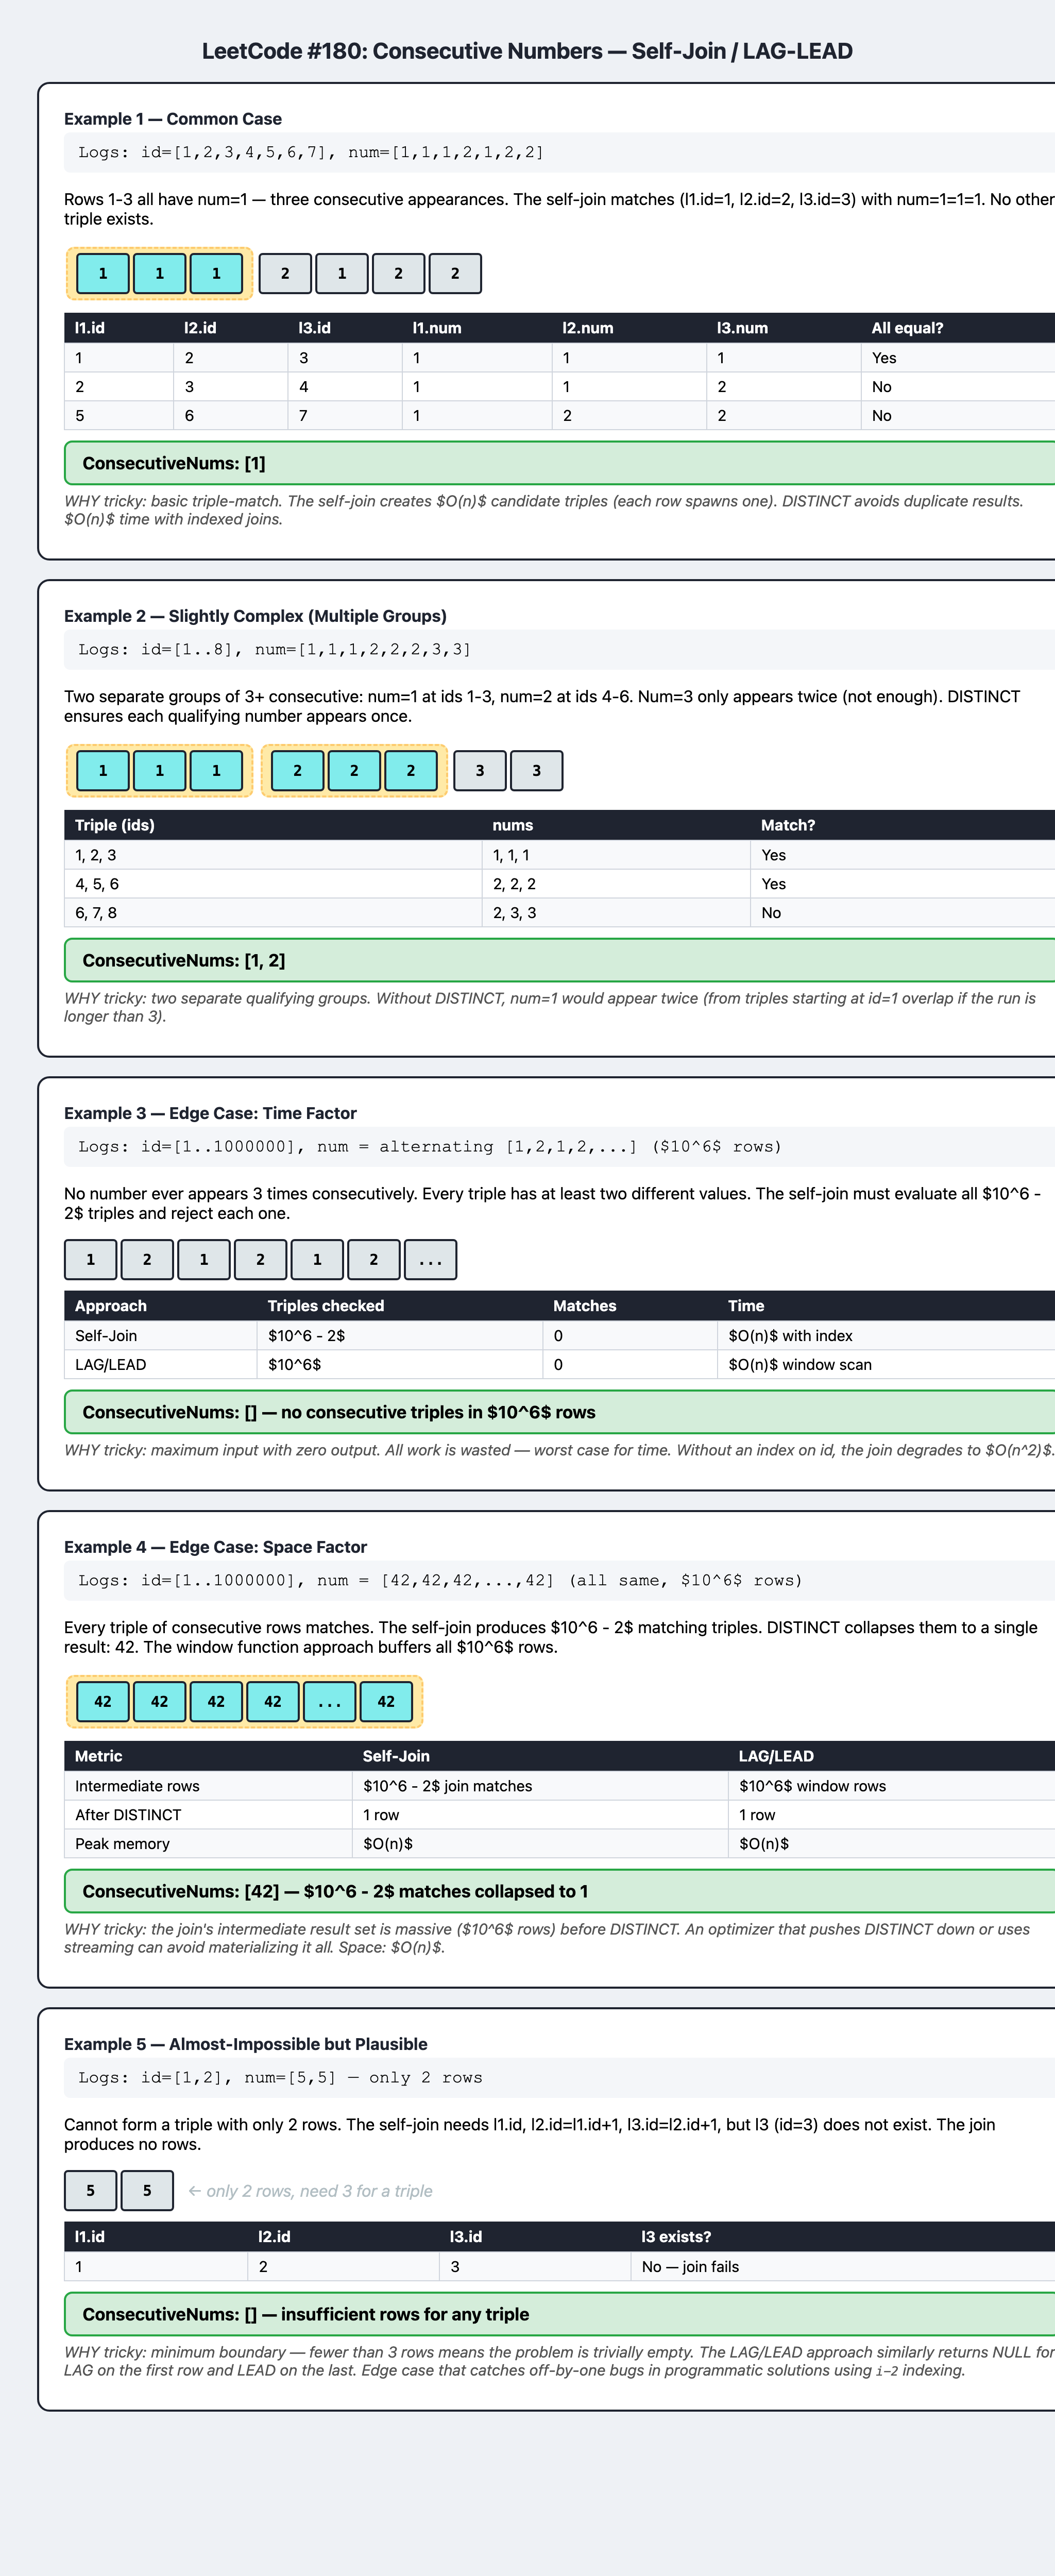